In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

In [2]:
%matplotlib inline

In [9]:
df = pd.read_csv("C:/Users/terrm/Downloads/Project/data/merged_raw.csv")

In [10]:
df.head()

,TransactionID,isFraud,TransactionDT,TransactionAmt,ProductCD,card1,card2,card3,card4,card5,...,id_31,id_32,id_33,id_34,id_35,id_36,id_37,id_38,DeviceType,DeviceInfo
0,2987000,0,86400,68.5,W,13926,NaN,150.0,discover,142.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2987001,0,86401,29.0,W,2755,404.0,150.0,mastercard,102.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,2987002,0,86469,59.0,W,4663,490.0,150.0,visa,166.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,2987003,0,86499,50.0,W,18132,567.0,150.0,mastercard,117.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,2987004,0,86506,50.0,H,4497,514.0,150.0,mastercard,102.0,...,samsung browser 6.2,32.0,2220x1080,match_status:2,T,F,T,T,mobile,SAMSUNG SM-G892A Build/NRD90M


In [11]:
print(f"Shape: {df.shape}")

Shape: (590540, 434)


In [12]:
print(f"Columns: {df.columns.tolist()[:10]} ... and {df.shape[1]-10} more")

Columns: ['TransactionID', 'isFraud', 'TransactionDT', 'TransactionAmt', 'ProductCD', 'card1', 'card2', 'card3', 'card4', 'card5'] ... and 424 more


In [13]:
df.info(verbose=True, show_counts=True)

<class 'pandas.DataFrame'>
RangeIndex: 590540 entries, 0 to 590539
Data columns (total 434 columns):
 #    Column          Non-Null Count   Dtype  
---   ------          --------------   -----  
 0    TransactionID   590540 non-null  int64  
 1    isFraud         590540 non-null  int64  
 2    TransactionDT   590540 non-null  int64  
 3    TransactionAmt  590540 non-null  float64
 4    ProductCD       590540 non-null  str    
 5    card1           590540 non-null  int64  
 6    card2           581607 non-null  float64
 7    card3           588975 non-null  float64
 8    card4           588963 non-null  str    
 9    card5           586281 non-null  float64
 10   card6           588969 non-null  str    
 11   addr1           524834 non-null  float64
 12   addr2           524834 non-null  float64
 13   dist1           238269 non-null  float64
 14   dist2           37627 non-null   float64
 15   P_emaildomain   496084 non-null  str    
 16   R_emaildomain   137291 non-null  str    
 17   

In [14]:
fraud_counts = df["isFraud"].value_counts()
fraud_rate = df["isFraud"].mean()

In [18]:

print(f"Not fraud : {fraud_counts[0]:,} ({1 - fraud_rate:.1%})")
print(f"Fraud     : {fraud_counts[1]:,} ({fraud_rate:.1%})")
print(f"\nFor every 1 fraud case there are {int(fraud_counts[0]/fraud_counts[1])} non-fraud cases")


Not fraud : 569,877 (96.5%)
Fraud     : 20,663 (3.5%)

For every 1 fraud case there are 27 non-fraud cases


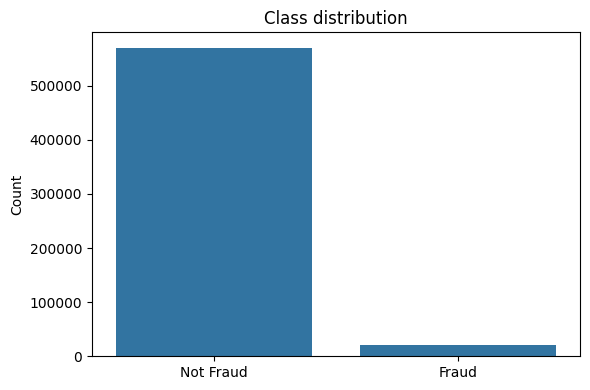

In [19]:
plt.figure(figsize=(6, 4))
sns.barplot(x=["Not Fraud", "Fraud"], y=fraud_counts.values)
plt.title("Class distribution")
plt.ylabel("Count")
plt.tight_layout()
plt.show()

In [22]:
null_rates = df.isnull().mean().sort_values(ascending=False)
null_rates = null_rates[null_rates > 0]

In [28]:
print(f"Columns with nulls: {len(null_rates)} out of {df.shape[1]}")
print(f"\nTop 20 worst columns by null rate:")
print(null_rates.head(20).to_string())

Columns with nulls: 414 out of 434

Top 20 worst columns by null rate:
id_24    0.991962
id_25    0.991310
id_07    0.991271
id_08    0.991271
id_21    0.991264
id_26    0.991257
id_27    0.991247
id_23    0.991247
id_22    0.991247
dist2    0.936284
D7       0.934099
id_18    0.923607
D13      0.895093
D14      0.894695
D12      0.890410
id_04    0.887689
id_03    0.887689
D6       0.876068
id_33    0.875895
id_09    0.873123


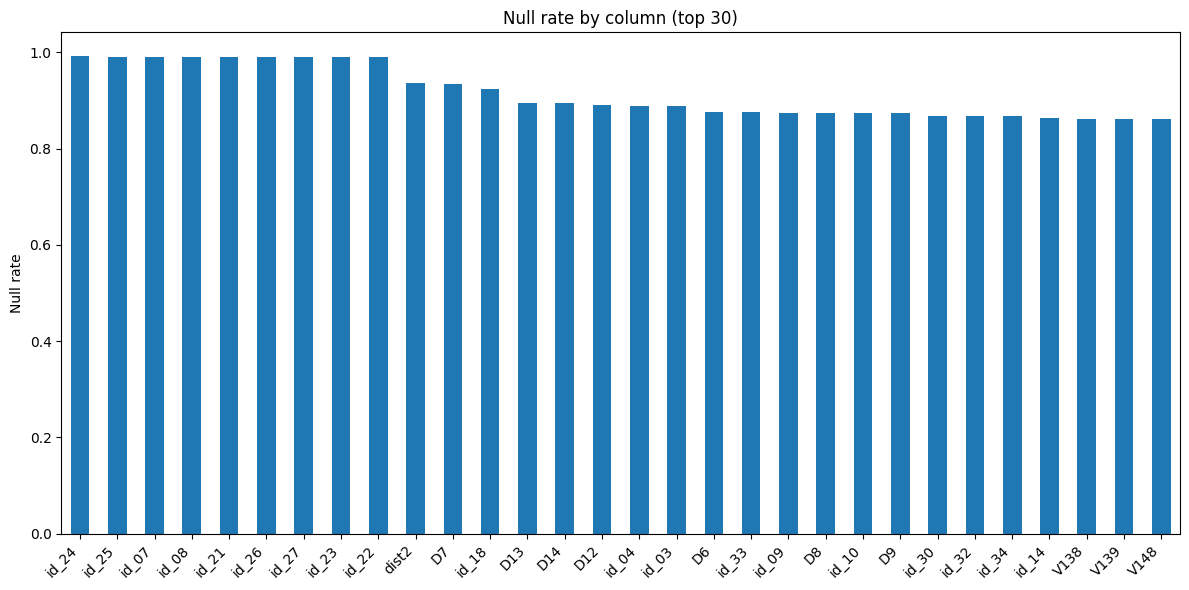

In [29]:
plt.figure(figsize=(12, 6))
null_rates.head(30).plot(kind="bar")
plt.title("Null rate by column (top 30)")
plt.ylabel("Null rate")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()


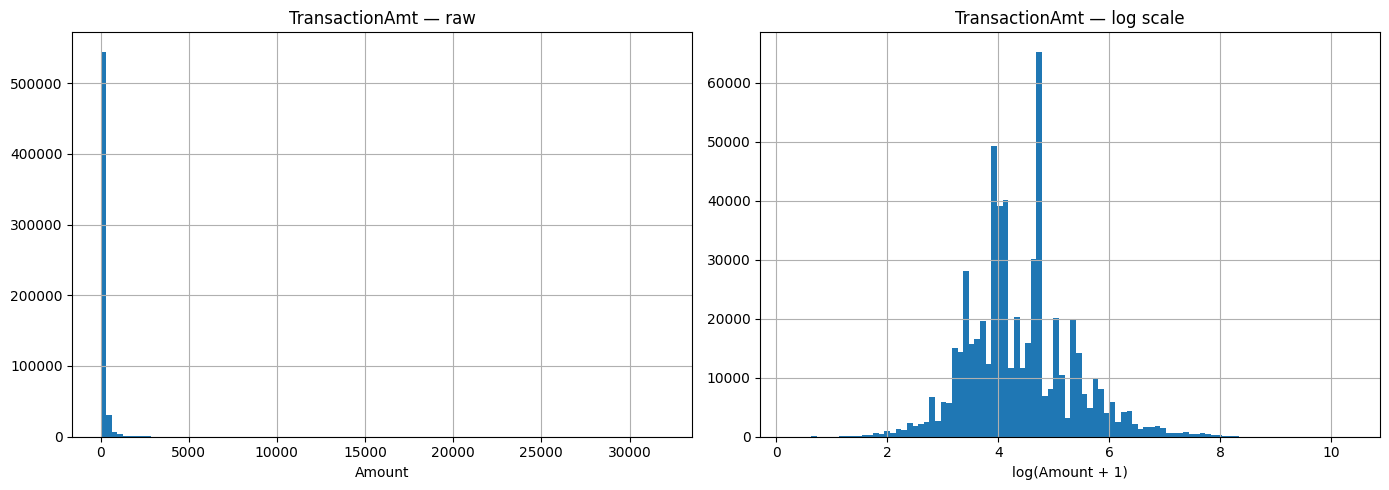

In [36]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# left chart — full distribution 
df["TransactionAmt"].hist(bins=100, ax=axes[0])
axes[0].set_title("TransactionAmt — raw")
axes[0].set_xlabel("Amount")

# right chart — log scale which makes the distribution readable
np.log1p(df["TransactionAmt"]).hist(bins=100, ax=axes[1])
axes[1].set_title("TransactionAmt — log scale")
axes[1].set_xlabel("log(Amount + 1)")

plt.tight_layout()
plt.show()

In [37]:
print(f"Min    : ${df['TransactionAmt'].min():.2f}")
print(f"Median : ${df['TransactionAmt'].median():.2f}")
print(f"Mean   : ${df['TransactionAmt'].mean():.2f}")
print(f"Max    : ${df['TransactionAmt'].max():.2f}")

Min    : $0.25
Median : $68.77
Mean   : $135.03
Max    : $31937.39


In [39]:
# cut transactions into 10 equal buckets

df["amt_bucket"] = pd.qcut(df["TransactionAmt"], q=10, duplicates="drop")

fraud_by_amt = df.groupby("amt_bucket")["isFraud"].mean()

In [43]:
df['amt_bucket'].value_counts()

amt_bucket
(68.769, 100.0]         73349
(100.0, 117.0]          72079
(35.95, 49.0]           65116
(25.95, 35.95]          61650
(49.0, 57.95]           59647
(0.25, 25.95]           59511
(275.293, 31937.391]    59053
(159.95, 275.293]       58390
(57.95, 68.769]         49346
(117.0, 159.95]         32399
Name: count, dtype: int64

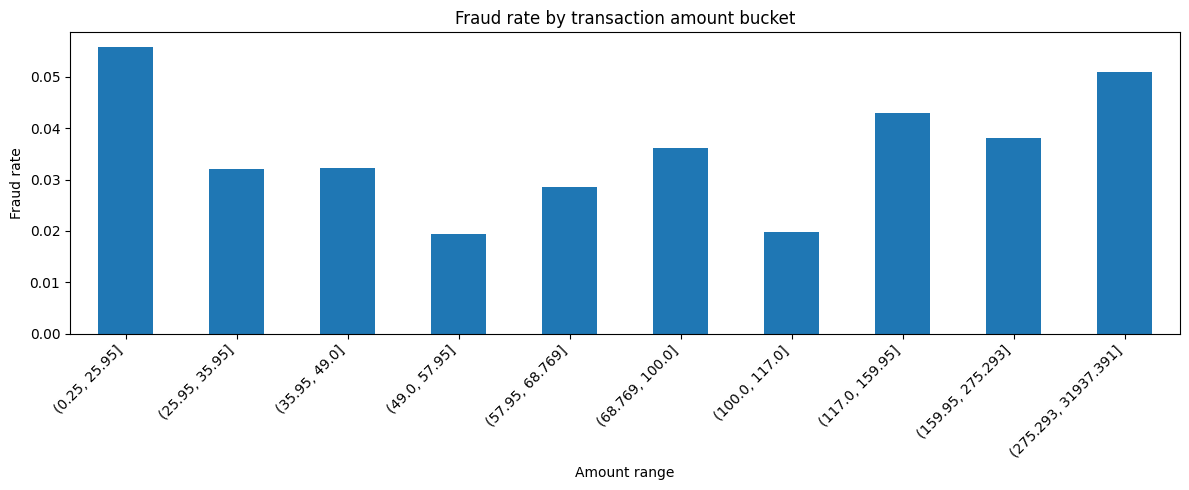

In [44]:
plt.figure(figsize=(12, 5))
fraud_by_amt.plot(kind="bar")
plt.title("Fraud rate by transaction amount bucket")
plt.ylabel("Fraud rate")
plt.xlabel("Amount range")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

In [52]:
df.drop(columns=["amt_bucket"], inplace=True)

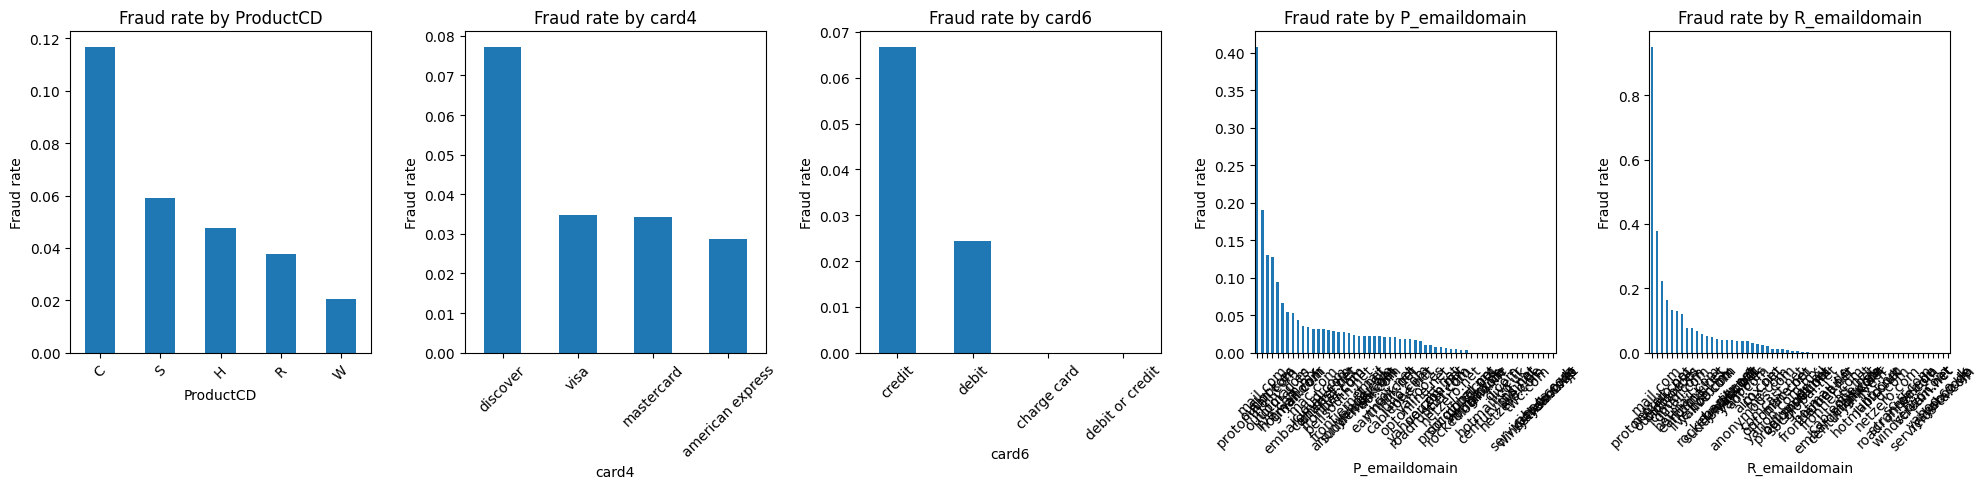

In [55]:
categorical_cols = ["ProductCD", "card4", "card6", "P_emaildomain", "R_emaildomain"]

fig, axes = plt.subplots(1, len(categorical_cols), figsize=(20, 5))

for i, col in enumerate(categorical_cols):
    if col in df.columns:
        fraud_rate_by_cat = df.groupby(col)["isFraud"].mean().sort_values(ascending=False)
        fraud_rate_by_cat.plot(kind="bar", ax=axes[i])
        axes[i].set_title(f"Fraud rate by {col}")
        axes[i].set_ylabel("Fraud rate")
        axes[i].tick_params(axis="x", rotation=45)

plt.tight_layout()
plt.show()

In [58]:
numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()

# calculate correlation of every numeric column with isFraud
correlations = df[numeric_cols].corr()["isFraud"].drop('isFraud')

# sort by absolute value so the strongest signals are at the top
correlations = correlations.reindex(
    correlations.abs().sort_values(ascending=False).index
)

Top 20 columns most correlated with fraud:

V257    0.383060
V246    0.366878
V244    0.364129
V242    0.360590
V201    0.328005
V200    0.318783
V189    0.308219
V188    0.303582
V258    0.297151
V45     0.281832
V158    0.278066
V156    0.275952
V149    0.273282
V228    0.268861
V44     0.260376
V86     0.251828
V87     0.251737
V170    0.249794
V147    0.242894
V52     0.239469


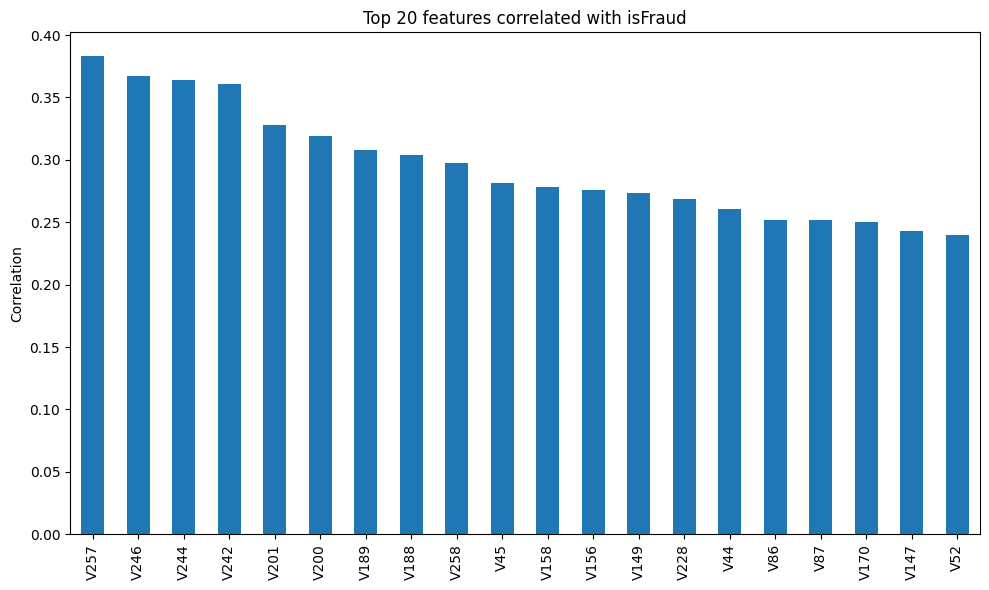

In [59]:
print("Top 20 columns most correlated with fraud:\n")
print(correlations.head(20).to_string())

# visualise top 20
plt.figure(figsize=(10, 6))
correlations.head(20).plot(kind="bar")
plt.title("Top 20 features correlated with isFraud")
plt.ylabel("Correlation")
plt.axhline(0, color="black", linewidth=0.5)
plt.tight_layout()
plt.show()

In [ ]:
### EDA findings — decisions for Stage 3

'''

- Fraud rate: ~3.5% — severe imbalance. Will use scale_pos_weight in XGBoost.
- Columns with >90% nulls: [ id_24, id_25, id_07, id_08, id_21, id_26, id_27, id_23, id_22, dist2, D7, id_18, D13, D14, D12] - will drop these
- TransactionAmt is highly skewed — will apply log transform.
- Strongest numerical predictors: [V257, V246, V244, V201, V200]
- customerID equivalent (TransactionID) — will DROP before training.
- Categorical columns to encode: ProductCD, card4, card6, P_emaildomain.
- Columns that need scaling: TransactionAmt, card1, card2, card3, card5.

'''
